sambungkan dgn s3

In [ ]:
import boto3
import pandas as pd
from io import StringIO

s3 = boto3.client(
    's3',
    aws_access_key_id='...',
    aws_secret_access_key='....',
    region_name='ap-southeast-1'
)

bucket = '51.65.98-gojek.review-bucket'
key = 'processed/gojek_review_clean.csv'

response = s3.get_object(Bucket=bucket, Key=key)

df = pd.read_csv(StringIO(response['Body'].read().decode('utf-8')))

df.head()

,review,rating,date
0,kumpulan driver sampah,1,2023-08-23
1,makin lama gojek makin ngga jelas susah bgt da...,1,2022-05-08
2,gojek akhir2 ini ngeselin driverny suka cancel...,3,2022-01-13
3,banyak maling dari driver gosend kurir sialan ...,1,2022-01-20
4,driver untuk area malang tolong di tambah musi...,5,2022-01-24


In [5]:
import matplotlib.pyplot as plt
from io import BytesIO

def save_plot_to_s3(filename):
    buffer = BytesIO()
    plt.savefig(buffer, format='png', bbox_inches='tight')
    buffer.seek(0)

    s3.put_object(
        Bucket=bucket,
        Key=f'processed/{filename}',
        Body=buffer,
        ContentType='image/png'
    )

    print(f"Saved plot → processed/{filename}")

In [ ]:
from io import StringIO

def save_csv_to_s3(df, filename):
    buffer = StringIO()
    df.to_csv(buffer, index=False)
    buffer.seek(0)

    s3.put_object(
        Bucket=bucket,
        Key=f'processed/{filename}',
        Body=buffer.getvalue(),
        ContentType='text/csv'
    )

    print(f"Saved CSV → processed/{filename}")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16957 entries, 0 to 16956
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  16957 non-null  object
 1   rating  16957 non-null  int64 
 2   date    16957 non-null  object
dtypes: int64(1), object(2)
memory usage: 397.6+ KB


In [7]:
#PREPROCESSING
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# drop null penting
df = df.dropna(subset=['review','rating','date'])

# buat kolom bulan
df['month'] = df['date'].dt.to_period('M')
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["year_month"] = df["date"].dt.to_period("M")

# panjang review
df['review_length'] = df['review'].astype(str).apply(lambda x: len(x.split()))

# **Analisis**

# **Hasil**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from collections import Counter

import nltk
from nltk import word_tokenize, pos_tag

In [ ]:
# 1. KATEGORI KEPUASAN

def kategori_kepuasan(rating):
    if rating >= 4:
        return "Puas"
    elif rating == 3:
        return "Netral"
    else:
        return "Tidak Puas"


df["kepuasan"] = df["rating"].apply(kategori_kepuasan)

print("\n=== 1. TABEL KATEGORI KEPUASAN ===")
kepuasan_table = df['kepuasan'].value_counts().reset_index()
kepuasan_table.columns = ['kategori','jumlah']
print(kepuasan_table)

# Visualisasi
ax = sns.barplot(data=kepuasan_table, x='kategori', y='jumlah', order=['Tidak Puas','Netral','Puas'])
plt.title('Kategori Kepuasan Pengguna Gojek')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Ulasan')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

# save ke s3
save_plot_to_s3("kepuasan_distribution.png")
save_to_s3("epuasan_distribution.csv")

plt.show()


=== 2. TABEL DISTRIBUSI RATING ===
   rating  jumlah_ulasan
0       1           8210
1       2           1524
2       3           1310
3       4            998
4       5           4915
Saved plot → processed/rating_distribution.png


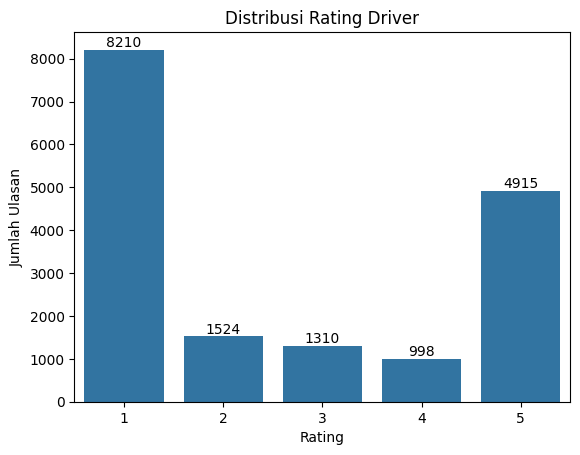

In [11]:
# 2. DISTRIBUSI RATING

print("\n=== 2. TABEL DISTRIBUSI RATING ===")
rating_table = df['rating'].value_counts().sort_index().reset_index()
rating_table.columns = ['rating','jumlah_ulasan']
print(rating_table)

ax = sns.barplot(data=rating_table, x='rating', y='jumlah_ulasan')
plt.title('Distribusi Rating Driver')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

save_plot_to_s3("rating_distribution.png")

plt.show()


=== 3. TREND RATING (FULL DATA) ===
year_month   rating
   2021-11 2.270538
   2021-12 2.274468
   2022-01 2.713092
   2022-02 2.698630
   2022-03 2.967148
   2022-04 2.641536
   2022-05 1.972628
   2022-06 3.426404
   2022-07 3.062774
   2022-08 3.000000
   2022-09 2.882466
   2022-10 2.843444
   2022-11 2.585366
   2022-12 2.740234
   2023-01 2.702703
   2023-02 2.816754
   2023-03 2.419283
   2023-04 2.190955
   2023-05 2.326226
   2023-06 2.693548
   2023-07 2.695652
   2023-08 2.592751
   2023-09 2.491682
   2023-10 2.493671
   2023-11 2.313230
   2023-12 2.091581
   2024-01 2.351648
   2024-02 2.320000
Saved → processed/trend_rating_per_bulan.png


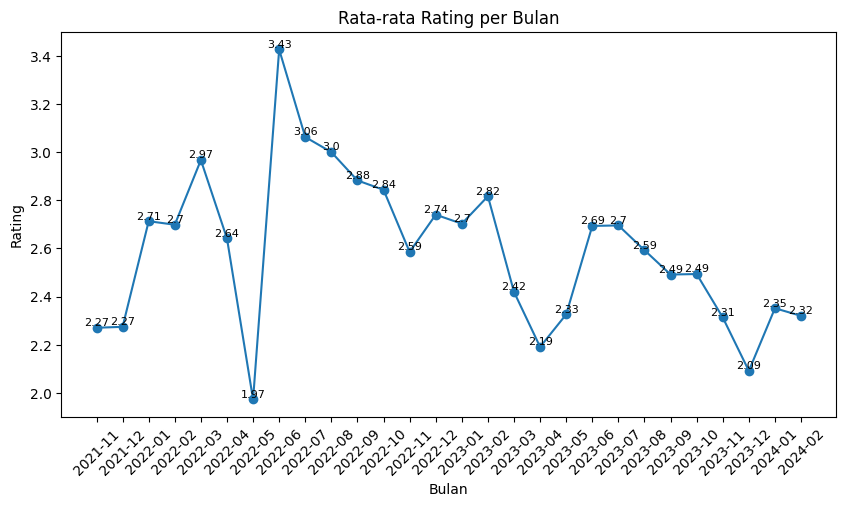

In [13]:
# 3. TREND RATA-RATA RATING PER BULAN

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['year_month'] = df['date'].dt.to_period('M').astype(str)

monthly_rating = (
    df.groupby('year_month')['rating']
    .mean()
    .reset_index()
    .sort_values('year_month')
)

print("\n=== 3. TREND RATING (FULL DATA) ===")
print(monthly_rating.to_string(index=False))

plt.figure(figsize=(10,5))

plt.plot(
    monthly_rating['year_month'],
    monthly_rating['rating'],
    marker='o'
)

plt.title('Rata-rata Rating per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rating')
plt.xticks(rotation=45)

for x, y in zip(monthly_rating['year_month'], monthly_rating['rating']):
    plt.text(x, y, round(y,2), ha='center', va='bottom', fontsize=8)

save_plot_to_s3("trend_rating_per_bulan.png")

plt.show()

Saved → processed/trend_kepuasan_per_bulan.png


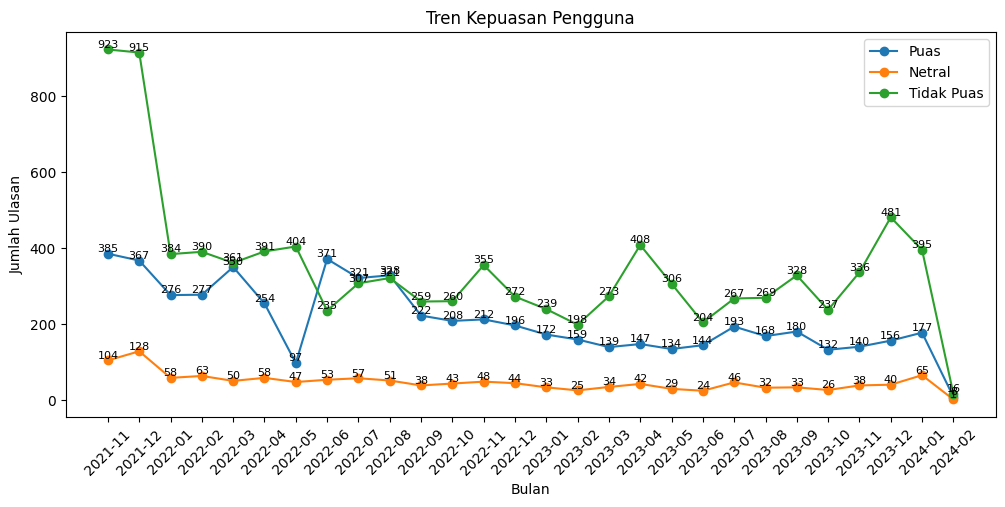

In [16]:
# Tren kepuasan Pelanggan per Bulan

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

df['year_month'] = df['date'].dt.to_period('M').astype(str)

all_months = pd.period_range(df['date'].min(), df['date'].max(), freq='M').astype(str)

def kategori_kepuasan(rating):
    if rating >= 4:
        return "Puas"
    elif rating == 3:
        return "Netral"
    else:
        return "Tidak Puas"

df['kepuasan'] = df['rating'].apply(kategori_kepuasan)

monthly_sentiment = df.groupby(['year_month','kepuasan']).size().unstack(fill_value=0)
monthly_sentiment = monthly_sentiment.sort_index()

plt.figure(figsize=(12,5))

plt.plot(monthly_sentiment.index, monthly_sentiment['Puas'], label='Puas', marker='o')
plt.plot(monthly_sentiment.index, monthly_sentiment['Netral'], label='Netral', marker='o')
plt.plot(monthly_sentiment.index, monthly_sentiment['Tidak Puas'], label='Tidak Puas', marker='o')

for x, y in zip(monthly_sentiment.index, monthly_sentiment['Puas']):
    plt.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=8)

for x, y in zip(monthly_sentiment.index, monthly_sentiment['Netral']):
    plt.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=8)

for x, y in zip(monthly_sentiment.index, monthly_sentiment['Tidak Puas']):
    plt.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=8)

plt.title("Tren Kepuasan Pengguna")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=45)
plt.legend()

save_plot_to_s3("trend_kepuasan_per_bulan.png")

plt.show()

In [92]:
# 5. TOP 3 ULASAN (RATING 1 & 5)

print("\n=== 5. TOP 3 ULASAN RATING 1 & 5 ===")

top_reviews = []

for r in [1, 5]:
    print(f"\n--- Rating {r} ---")
    
    temp = df[df['rating'] == r].copy()
    temp = temp.sort_values('review_length', ascending=False)

    top3 = temp[['review', 'review_length']].head(3)

    print(top3.to_string(index=False))

    top3['rating'] = r

    top_reviews.append(top3)

top_reviews_df = pd.concat(top_reviews)

save_to_s3(top_reviews_df, "top_reviews_rating_1_5.csv")


=== 5. TOP 3 ULASAN RATING 1 & 5 ===

--- Rating 1 ---
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    review  review_length
ajarin driver sop untuk ramah ke pelanggan dari awal pick up muka udh jutek oke saya b aja pas jln nya pelan pdhl saya udh mintol dgn sopan pak maaf jln nya bsa cepet gk saya dah telat tpi dia jawab ketus oke saya msh sabar pas di jln saya di salahin sama driver nya mba harus nya tau dong lokasi nya dmna kan jadi nya nyasar hello gua naik ojol tuh emang gk tau alamat nya trs ngapain gua naik ojol kalo gua yg harus cari tau alamat nya padahal udh tag 

In [76]:
def clean_text(text):
    text = str(text).lower()
    text = text.replace("gk", "tidak")
    text = text.replace("ga", "tidak")
    text = text.replace("tdk", "tidak")
    text = text.replace("bgt", "banget")
    text = text.replace("driv", "driver")
    text = text.replace("bgus", "bagus")
    return text


Top kata rating 1:
[('tidak', 4606), ('lama', 1581), ('banget', 1226), ('kecewa', 495), ('mahal', 468), ('parah', 371), ('buruk', 279), ('baik', 235), ('jelek', 221), ('murah', 187)]
Saved plot → processed/wordcloud_rating_1.png


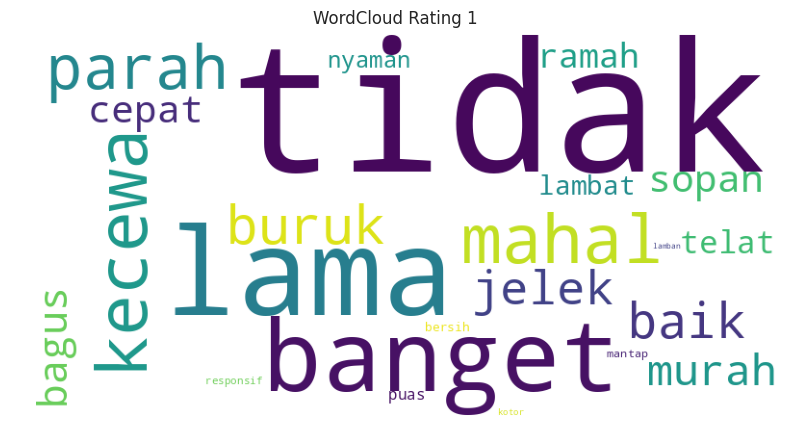


Top kata rating 5:
[('ramah', 1459), ('tidak', 788), ('baik', 732), ('cepat', 463), ('sopan', 445), ('bagus', 416), ('banget', 332), ('mantap', 187), ('lama', 163), ('nyaman', 122)]
Saved plot → processed/wordcloud_rating_5.png


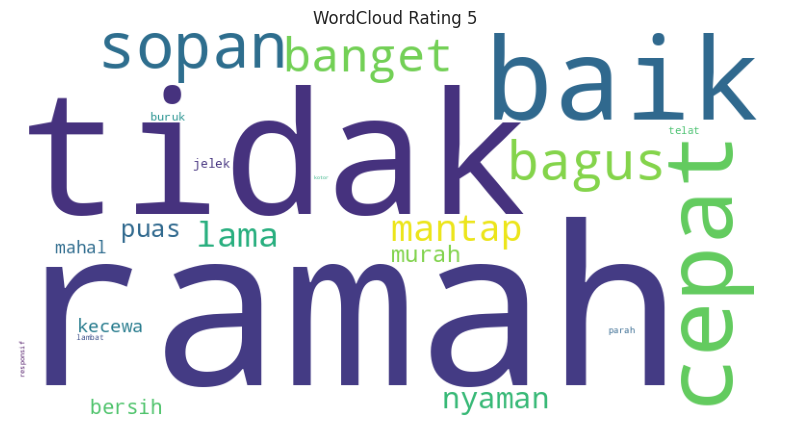

In [93]:
adjective_list = [
    "cepat","lambat","ramah","sopan","baik","buruk",
    "jelek","bagus","parah","lama","nyaman","bersih",
    "kotor","murah","mahal","puas","kecewa","mantap",
    "telat","sigap","responsif","lamban","banget","tidak"
]

def extract_keywords(text):
    text = clean_text(text)
    words = re.findall(r'[a-zA-Z]+', text)
    return [w for w in words if w in adjective_list]


def make_wordcloud(rating):
    text = ' '.join(df[df['rating']==rating]['review'].astype(str))
    words = extract_keywords(text)
    freq = Counter(words)

    print(f"\nTop kata rating {rating}:")
    print(freq.most_common(10))

    if len(freq) == 0:
        print("Tidak ada kata ditemukan")
        return

    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate_from_frequencies(freq)

    plt.imshow(wc)
    plt.axis('off')
    plt.title(f'WordCloud Rating {rating}')
    save_plot_to_s3(f"wordcloud_rating_{rating}.png")
    plt.show()

make_wordcloud(1)
make_wordcloud(5)